<a href="https://colab.research.google.com/github/bookwork123/MachineLearning/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
# task 1 - load the data into a pandas DataFrame
df = pd.read_csv('cybersecurity_intrusion_data.csv')

In [ ]:
# task 2 - use structural inspection methods to analyze features
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 670.7+ KB


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000


In [ ]:
# task #3 - drop any non-informative identifiers
# I chose to drop browser_type since it seemed like the least informative value or the least related to an attack. I also chose to drop unusual_time_access as that
# to me, seemed the next least informative.
df = df.drop(['session_id', 'browser_type', 'unusual_time_access'], axis=1)

In [ ]:
# task #4 - quantify any missing values across the columns and implement a structured imputation strategy to handle missing entries
df.isnull().sum()
df['encryption_used'] = df['encryption_used'].fillna(df['encryption_used'].mode()[0])
# From the first command I learned that 'encryption_used' was the only column with missing values, so for every null entry in that column,
# I replaced the null value with the most counted encryption method (the mode), which was AES, since it was a categorical variable.
# This would be equivalent to using the mean on a numerical attribute

In [ ]:
# task #5 - Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (e.g., StandardScaler)
#           to numerical columns and encoding (e.g., OneHotEncoder) to categorical columns.
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_attributes = list(df.drop(['protocol_type', 'encryption_used'], axis=1))
cat_attributes = ['protocol_type', 'encryption_used']

transformation = ColumnTransformer([
    ("num", StandardScaler(), num_attributes),
    ("cat", OneHotEncoder(), cat_attributes),
])

df_prepared = transformation.fit_transform(df)

In [ ]:
# task #6 - Compute the Pearson correlation matrix for the numerical features,
#           generate a Seaborn heatmap with annotations, and create at least two distribution plots
#           and one scatter plot to examine feature relationships and the target variable (attack_detected).
import seaborn as sns
import matplotlib.pyplot as plt

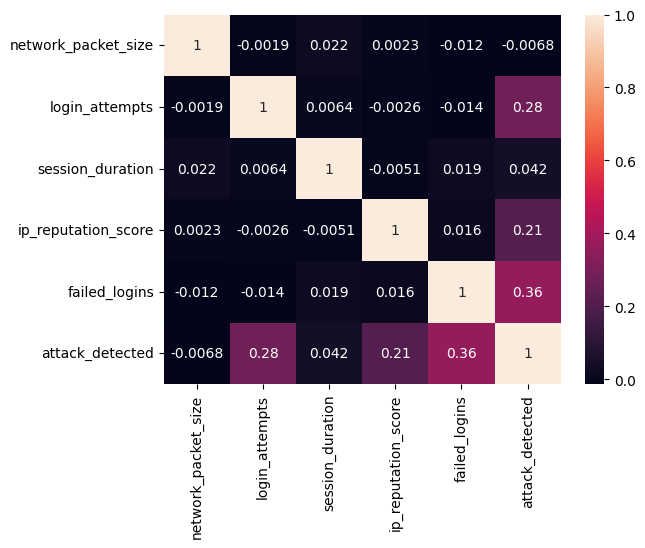

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn heatmap w/ annotations
matrix = df[num_attributes].corr(method='pearson')
sns.heatmap(matrix, annot=True)
plt.show()

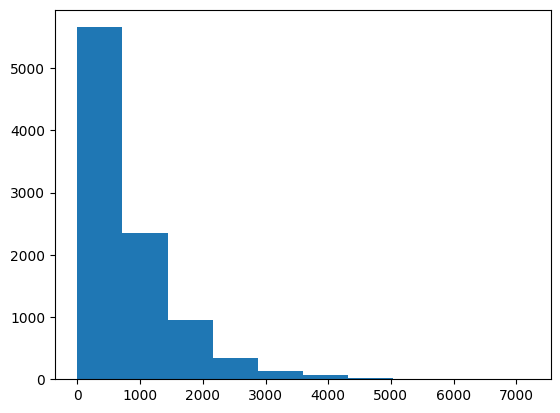

In [36]:
#histogram of session_duration
plt.hist(df['session_duration'])
plt.show()

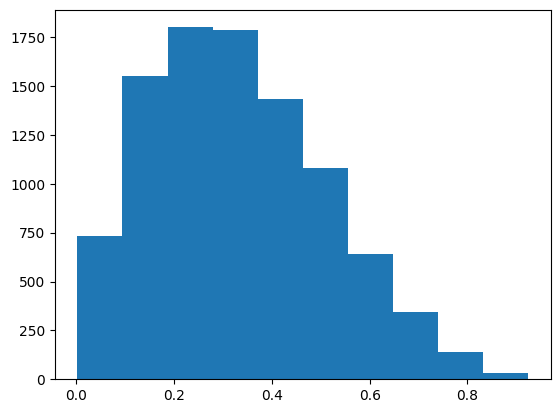

In [37]:
# histogram of ip_reputation_score
plt.hist(df['ip_reputation_score'])
plt.show()

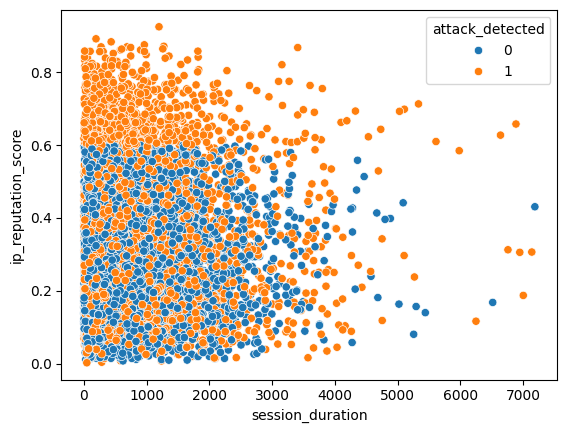

In [35]:
# scatter plot of session_duration and ip_reputation_score
sns.scatterplot(data=df, x='session_duration', y='ip_reputation_score', hue='attack_detected')
plt.show()